In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike 

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [ ]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_run3_resume/sampler_state.pkl')

In [3]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [4]:
sampler.inv_covariances_list

[array([[[ 3.23870086e+001,  3.31278471e-001, -3.15511720e-002,
           7.89217076e-004, -3.28333834e-001],
         [ 3.31278471e-001,  3.80064037e+001, -6.69111758e-001,
           9.53269837e-001, -4.55230554e-001],
         [-3.15511720e-002, -6.69111758e-001,  3.48459254e+001,
          -8.21470751e-002, -8.85111526e-001],
         [ 7.89217076e-004,  9.53269837e-001, -8.21470751e-002,
           3.23942821e+001, -6.08938380e-001],
         [-3.28333834e-001, -4.55230554e-001, -8.85111526e-001,
          -6.08938380e-001,  4.03949351e+001]],
 
        [[ 9.63483552e+009,  9.91782992e+006,  9.68906275e+007,
          -1.57062648e+007,  1.96857917e+008],
         [ 9.91782992e+006,  9.68085207e+009, -1.92624570e+007,
           7.16890779e+007, -9.74462894e+007],
         [ 9.68906275e+007, -1.92624570e+007,  9.32569391e+009,
          -2.53543534e+008, -2.68580667e+008],
         [-1.57062648e+007,  7.16890779e+007, -2.53543534e+008,
           9.60083780e+009, -7.62562963e+007]

In [ ]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.47251061, 0.52265626, 0.42879419, 0.54076251, 0.5630816 ],
        [0.39409421, 0.48496165, 0.01664841, 0.49201778, 0.51227292],
        [0.59970292, 0.72958107, 0.52354275, 0.35461991, 0.78338907],
        ...,
        [0.49451742, 0.36539727, 0.58435197, 0.3269909 , 0.69878482],
        [0.55954706, 0.43408606, 0.71334673, 0.15227776, 0.61494676],
        [0.59331854, 0.42845879, 0.82737686, 0.01116315, 0.61042279]],
       shape=(100000, 5))]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([32.27316315,  0.10255458,  0.61119538, ..., 29.99060949,
        11.29798844, 10.24662985], shape=(100000,))]

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))

# maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt4 = prior_transform(proc_pt[3][np.argmax(logden_list)].reshape(1, -1))


In [ ]:
maxld_pt1

array([[6.01174406, 1.00274894, 0.72620898, 8.85138181, 0.39710375]])

In [9]:
log_density(maxld_pt1)

array([5.86732009])

In [10]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [11]:
gwf.rhostat(h_pt1)

array(5.98629499)

In [12]:
gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(5.89107635), array(0.30035121))

In [13]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

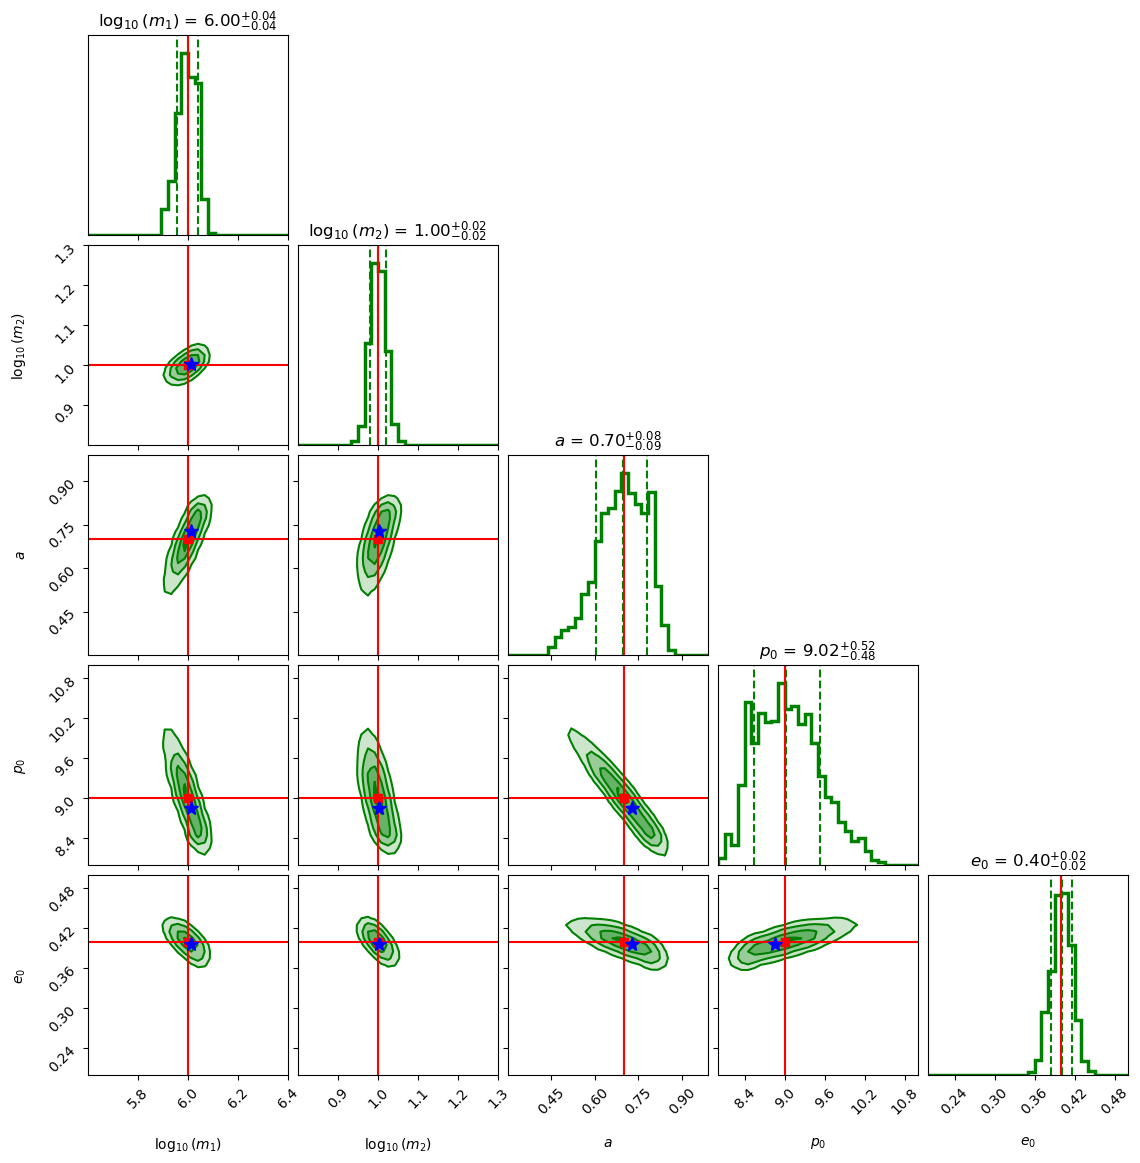

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




# connection plot

In [15]:
# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
import loglike 
loglike_nont = loglike.LogLike(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_nont.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)

Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127


In [16]:
loglike_nont

In [33]:
# TEMP for annealing
def templogden(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            # NOTE: scaled by temp
            loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

def templogden_nont(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            # NOTE: scaled by temp
            loglike = loglike_nont(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

In [34]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [35]:
proc1_maxld_pt = maxld_pt1.copy()


In [36]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 100
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]

#NOTE: extended plots till it hits prior boundaries

# prior_lo = np.array([r[0] for r in param_ranges])
# prior_hi = np.array([r[1] for r in param_ranges])

# start = proc1_maxld_pt_1d
# direction = true_pt - proc1_maxld_pt_1d
# #iterate thru each dim
# t_lows, t_highs = [], []
# for i in range(len(start)):
#     if direction[i] > 0:
#         t_lows.append((prior_lo[i] - start[i]) / direction[i])
#         t_highs.append((prior_hi[i] - start[i]) / direction[i])
#     elif direction[i] < 0:
#         t_lows.append((prior_hi[i] - start[i]) / direction[i])
#         t_highs.append((prior_lo[i] - start[i]) / direction[i])
#     else:
#         t_lows.append(-np.inf)
#         t_highs.append(np.inf)

# t_min = max(t_lows)   # most restrictive lower bound
# t_max = min(t_highs)  # most restrictive upper bound

# n_points = 50
# t_vals1    = np.sort(np.unique(np.concatenate([np.linspace(t_min, t_max, n_points), [0.0, 1.0]])))

# # t_values = np.linspace(t_min, t_max, n_points)
# line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [37]:
# n_points = 50

# # Per-dimension line points: t range set by each dim's own prior bounds
# t_values_per_dim = []
# line_points_per_dim = []

# for i in range(len(start)):
#     if direction[i] > 0:
#         t_lo = (prior_lo[i] - start[i]) / direction[i]
#         t_hi = (prior_hi[i] - start[i]) / direction[i]
#     elif direction[i] < 0:
#         t_lo = (prior_hi[i] - start[i]) / direction[i]
#         t_hi = (prior_lo[i] - start[i]) / direction[i]
#     else:
#         t_lo, t_hi = 0, 1  # direction[i]==0, fixed dim
    
#     t_vals = np.linspace(t_lo, t_hi, n_points)
#     t_values_per_dim.append(t_vals)
#     line_points_per_dim.append(start[:, np.newaxis] + t_vals * direction[:, np.newaxis])


In [38]:
logden_theory_proc1 = []
logden_theory_proc1.append(templogden(np.array(line_points_proc1).T))


In [39]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()
logden_theory_proc1

array([5.86732009, 5.86814077, 5.86951688, 5.87144471, 5.87384762,
       5.87656798, 5.87937254, 5.88195107, 5.88391691, 5.88480477,
       5.88407825, 5.88111884, 5.87523912, 5.86567583, 5.85160297,
       5.83212434, 5.8062886 , 5.77308831, 5.73244431, 5.68335677,
       5.6510901 , 5.70899205, 5.76021615, 5.80536796, 5.84134002,
       5.86571748, 5.87662751, 5.87572288, 5.85795481, 5.8212591 ,
       5.76707865, 5.69150596, 5.67002206, 5.75494425, 5.81802058,
       5.86026702, 5.87626067, 5.86477318, 5.8235205 , 5.74953135,
       5.64245436, 5.73594207, 5.81788673, 5.86556852, 5.87262863,
       5.84030015, 5.76136076, 5.63725942, 5.75528921, 5.83910425,
       5.8746316 , 5.85682914, 5.78110222, 5.64707947, 5.7636399 ,
       5.85228156, 5.87708276, 5.8341494 , 5.72211539, 5.71654263,
       5.83572583, 5.88022737, 5.84447357, 5.72491267, 5.72873156,
       5.84935667, 5.88158572, 5.81958671, 5.66047413, 5.7981341 ,
       5.88146998, 5.86003841, 5.72925784, 5.76008227, 5.87500

In [40]:
logden_theory_proc1_nont = []
logden_theory_proc1_nont.append(templogden_nont(np.array(line_points_proc1).T))


In [41]:
logden_theory_proc1_nont = np.array(logden_theory_proc1_nont).flatten()
logden_theory_proc1_nont

array([0.04405987, 0.04426657, 0.04453328, 0.0448596 , 0.04524425,
       0.04568456, 0.04617684, 0.04671607, 0.04729548, 0.04790677,
       0.04853946, 0.04918083, 0.0498156 , 0.05042539, 0.0509885 ,
       0.05147952, 0.05186934, 0.05212481, 0.05220906, 0.05208198,
       0.05170136, 0.05102426, 0.0500093 , 0.04861888, 0.0468236 ,
       0.04460508, 0.04196021, 0.03890661, 0.035486  , 0.03177035,
       0.02787151, 0.02395511, 0.02027256, 0.01720671, 0.01529184,
       0.01502421, 0.01643959, 0.0190708 , 0.02237733, 0.02598515,
       0.02967332, 0.03331004, 0.03680732, 0.04009406, 0.04309913,
       0.04574341, 0.04793634, 0.04957798, 0.05056732, 0.05081615,
       0.05026776, 0.04891911, 0.04684151, 0.04419858, 0.04125536,
       0.03837507, 0.03599241, 0.03454236, 0.0343377 , 0.03545372,
       0.03771993, 0.0408335 , 0.04449005, 0.04844666, 0.05250751,
       0.05646288, 0.06003083, 0.06285884, 0.06460942, 0.06507931,
       0.06425324, 0.06226758, 0.05939136, 0.05614567, 0.05349

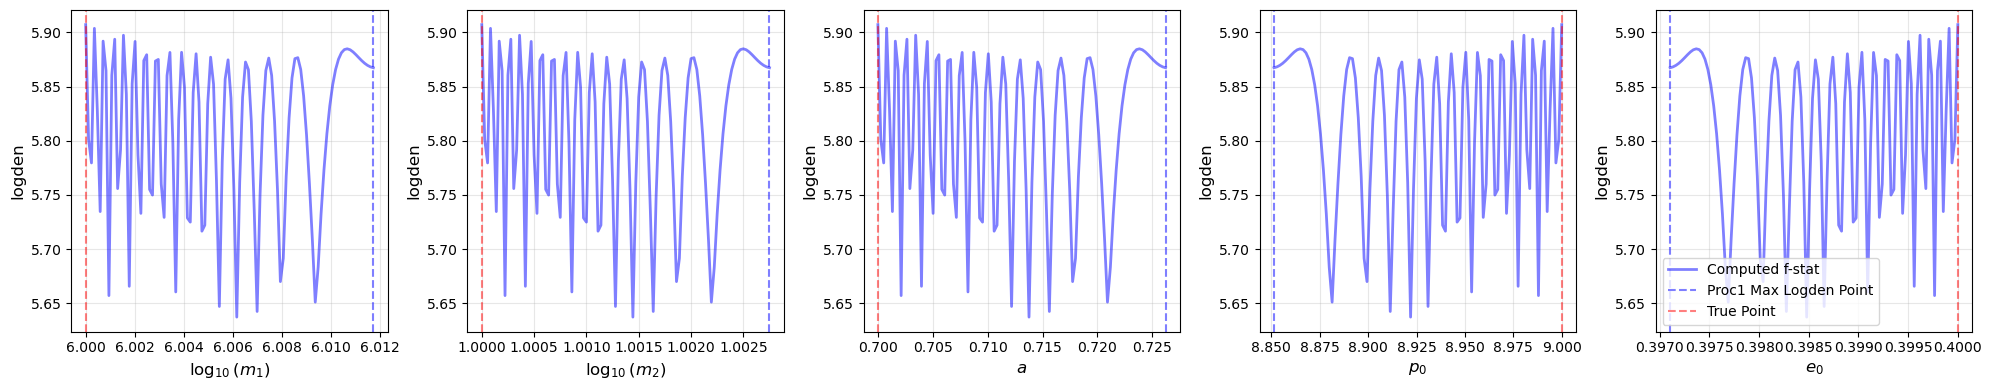

In [42]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


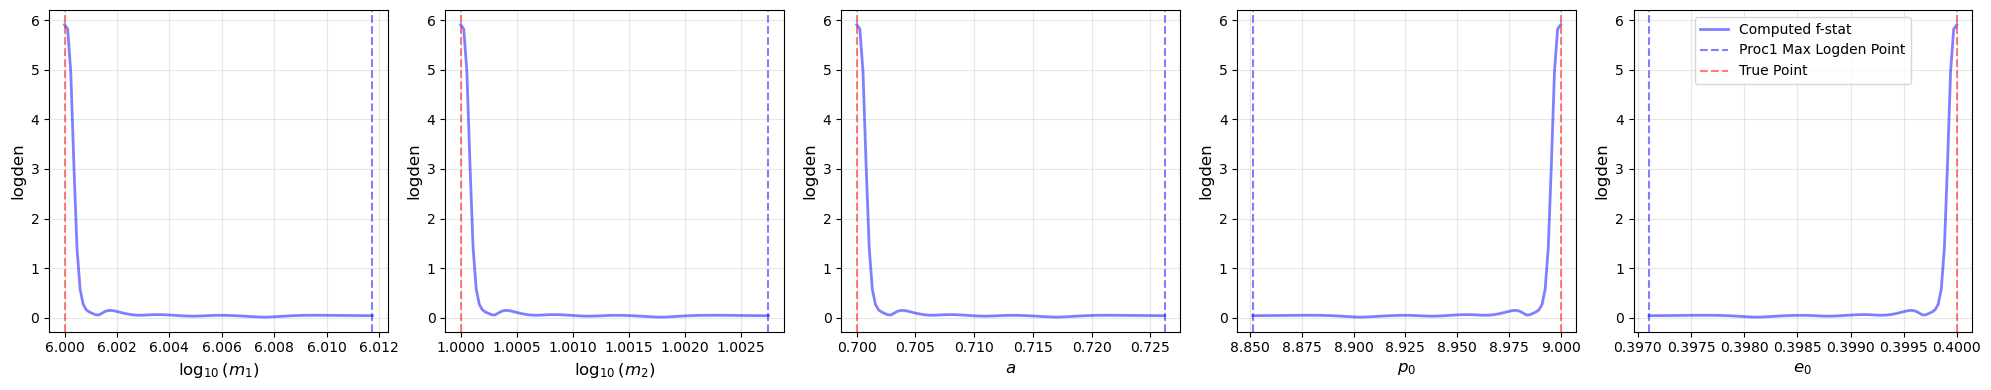

In [43]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1_nont, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [44]:
templates_proc1 = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T)
    templates_proc1.append(template)

In [45]:
X_proc1 = []
for template in templates_proc1:
    X = gwf.Xstat_timemax(data, template)
    X_proc1.append(X.get())

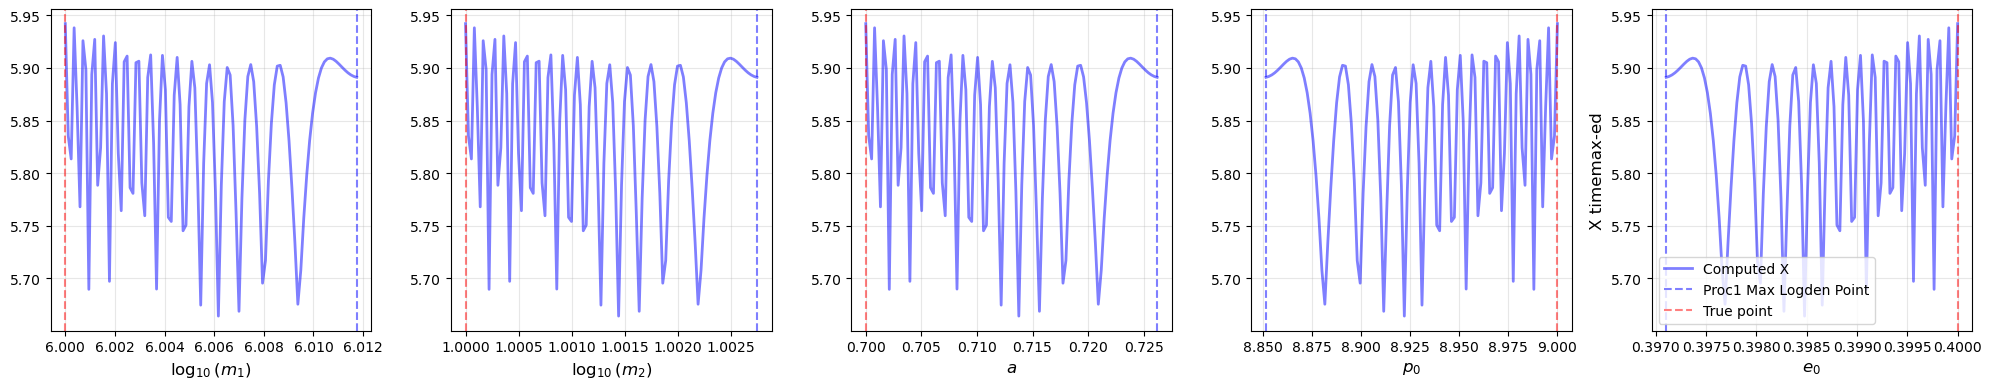

In [46]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('X timemax-ed', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [47]:
X_proc1_nont = []
for template in templates_proc1:
    X = gwf.Xstat(data, template)
    X_proc1_nont.append(X.get())

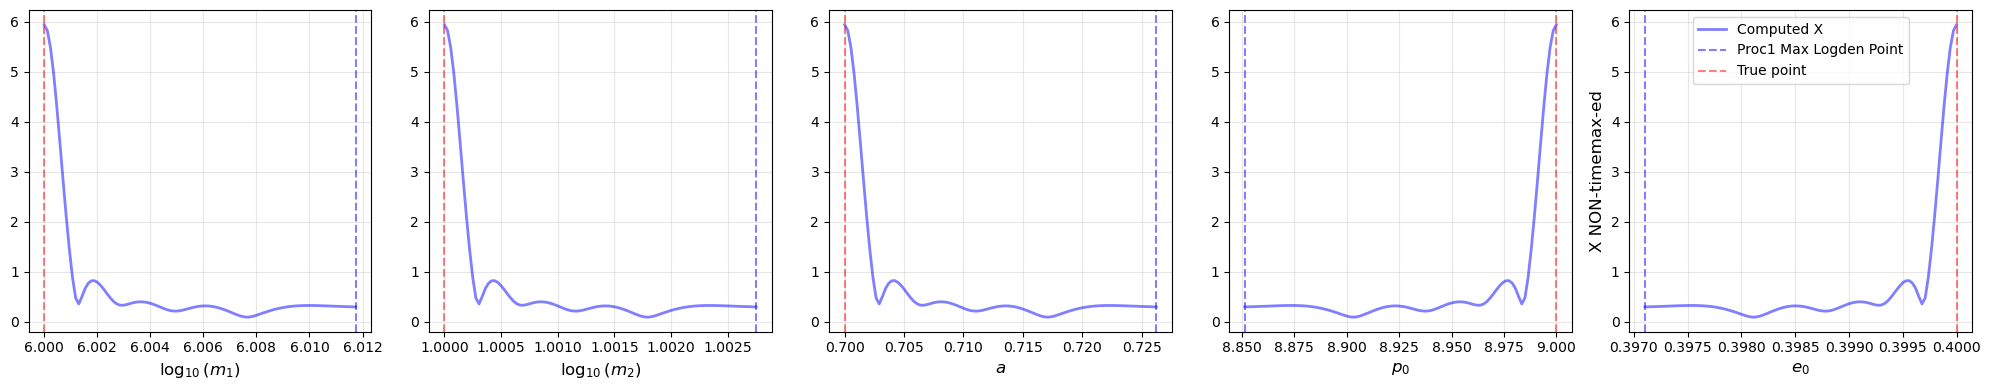

In [48]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('X NON-timemax-ed', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1_nont, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [49]:
print("Creating GravWaveAnalysis class...")
gwf_2yr = GWfuncs.GravWaveAnalysis(2, dt)

print("Initializing loglike class...")


loglike_obj_2yr = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf_2yr,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj_2yr.signal
data_snr = gwf_2yr.rhostat(data)
print('SNR calculated:', data_snr)

Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 32.86622400746991


In [50]:
loglike_nont_2yr = loglike.LogLike(
    params_star,
    waveform_gen_comb,
    gwf_2yr,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_nont_2yr.signal
data_snr = gwf_2yr.rhostat(data)
print('SNR calculated:', data_snr)

Done initializing loglike class.
Calculating SNR...
SNR calculated: 32.86622400746991


In [51]:
def templogden_2yr(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            # NOTE: scaled by temp
            loglike = loglike_obj_2yr(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

def templogden_nont_2yr(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            # NOTE: scaled by temp
            loglike = loglike_nont_2yr(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

In [52]:
logden_theory_proc1_2yr = []
logden_theory_proc1_2yr.append(templogden_nont_2yr(np.array(line_points_proc1).T))


In [54]:
logden_theory_proc1_2yr = np.array(logden_theory_proc1_2yr).flatten()
logden_theory_proc1_2yr

array([6.94720461e-04, 7.62194340e-04, 7.56231027e-04, 7.23475363e-04,
       7.75013222e-04, 7.52263242e-04, 7.17313656e-04, 7.69202299e-04,
       7.77767091e-04, 7.34103109e-04, 7.33568438e-04, 7.62255857e-04,
       7.89825743e-04, 7.85662887e-04, 7.26015340e-04, 7.38215236e-04,
       7.61053566e-04, 7.89497506e-04, 8.30920921e-04, 8.02612054e-04,
       7.99083819e-04, 7.59298476e-04, 7.73249052e-04, 7.39414348e-04,
       7.62680455e-04, 7.66348838e-04, 7.54311272e-04, 7.91922815e-04,
       7.64623422e-04, 7.86148994e-04, 7.99925368e-04, 7.64813090e-04,
       8.11190877e-04, 8.31579976e-04, 8.41131196e-04, 8.79665478e-04,
       9.35952842e-04, 9.43867150e-04, 8.94353623e-04, 8.44806873e-04,
       8.49756385e-04, 9.13269216e-04, 9.97541408e-04, 9.80986871e-04,
       9.17352865e-04, 8.77480638e-04, 9.80324784e-04, 1.00669763e-03,
       9.23378949e-04, 9.62197227e-04, 1.05657746e-03, 1.00011938e-03,
       9.85952778e-04, 1.09933132e-03, 1.01815232e-03, 1.06369485e-03,
      

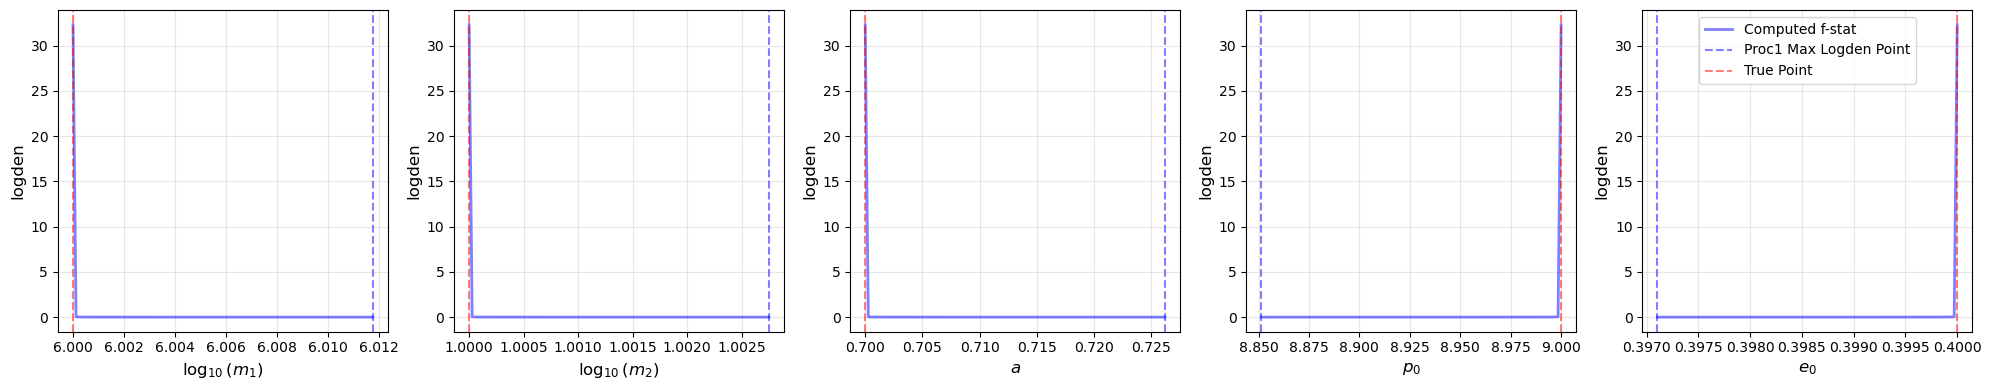

In [55]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1_2yr, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [68]:
logden_theory_proc1_2yr_t = []
logden_theory_proc1_2yr_t.append(templogden_2yr(np.array(line_points_proc1).T))


In [69]:
logden_theory_proc1_2yr_t = np.array(logden_theory_proc1_2yr_t).flatten()
logden_theory_proc1_2yr_t

array([ 0.1098099 ,  0.11108018,  0.11268814,  0.11377403,  0.11508469,
        0.11647438,  0.1172134 ,  0.11787993,  0.1185252 ,  0.11869078,
        0.11847006,  0.11800165,  0.11746184,  0.11630515,  0.1150491 ,
        0.11567953,  0.11797023,  0.12033187,  0.12336379,  0.12962265,
        0.13835491,  0.14650228,  0.15229875,  0.15556992,  0.15554656,
        0.15228691,  0.14723267,  0.1408235 ,  0.13595703,  0.14228315,
        0.14920318,  0.16189821,  0.17619153,  0.18398775,  0.182879  ,
        0.17431253,  0.16269326,  0.15393715,  0.16599605,  0.18102128,
        0.20169755,  0.21120795,  0.20475864,  0.18832283,  0.17101993,
        0.18644279,  0.20875507,  0.23420313,  0.23718664,  0.21797613,
        0.19407755,  0.20565569,  0.23595493,  0.26539379,  0.2612601 ,
        0.23182028,  0.20719725,  0.24990413,  0.29142746,  0.2977559 ,
        0.26301968,  0.22815956,  0.28422589,  0.33197692,  0.32676137,
        0.28084988,  0.27470057,  0.34922282,  0.38360038,  0.34

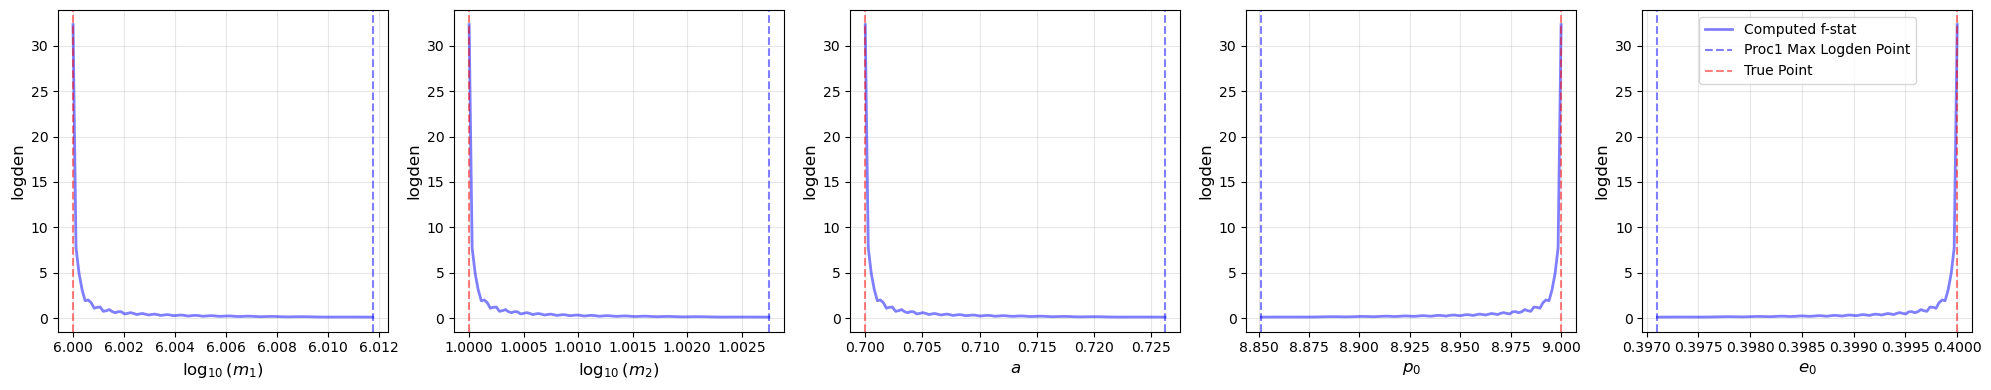

In [70]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1_2yr_t, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [56]:
templates_proc1_2yr = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=2)
    templates_proc1_2yr.append(template)

In [63]:
data = loglike_obj_2yr.signal


In [65]:
X_proc1_2yr = []
for template in templates_proc1_2yr:
    X = gwf_2yr.Xstat(data, template)
    X_proc1_2yr.append(X.get())

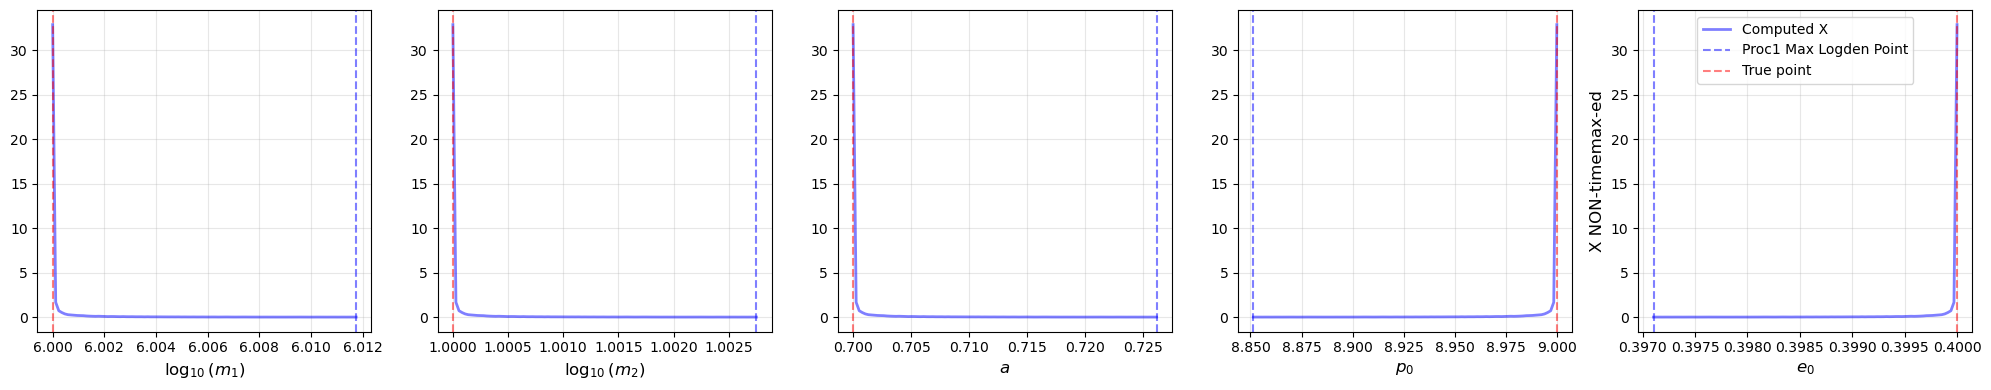

In [67]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('X NON-timemax-ed', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1_2yr, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [ ]:
amp = getattr(waveform_gen_sep.waveform_generator, 'amplitude_generator', None)    
mode_forms = []

for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    
    # Generate waveforms for each GROUP (not combined)
    waveforms_per_group = []
    for group in groups:
        mode_form_group = waveform_gen_sep(m1, m2, a, p0, e0, xI0, dist,
                                          qS, phiS, qK, phiK, 
                                          Phi_phi0, Phi_theta0, Phi_r0,
                                          dt=dt, T=T,
                                          mode_selection=group,  # Pass group list
                                          include_minus_mkn=False)
        # Sum all modes within this group
        mode_form_summed = np.sum(mode_form_group, axis=1)
        waveforms_per_group.append(mode_form_summed)
    
    # Stack into array: shape (N_samples, N_groups)
    mode_form = np.stack(waveforms_per_group, axis=1)
    mode_forms.append(mode_form)


In [ ]:
rhostats_proc1 = []
for hm_arr in mode_forms:
    rhostats_proc1.append(gwf.rhostat_modes(hm_arr.T))

In [ ]:
Xm_proc1 = []
for idx, hm_arr in enumerate(mode_forms):
    X_mode = gwf.Xmstat_timemax(data, hm_arr.T, rhostats_proc1[idx])
    Xm_proc1.append(X_mode)    

In [ ]:
chi2_proc1 = []
for i in range(len(mode_forms)):
    chi2 = gwf.chi_sq(Xm_proc1[i], rhostats_proc1[i])
    chi2_proc1.append(chi2.get())

In [ ]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('chi2', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], chi2_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label=r'Computed $\chi^2$')
    # ax.plot(line_points_proc2[dim], chi2_proc2, '-', 
    #         color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    # ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
    #            alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)
 
plt.legend()
plt.tight_layout()


In [ ]:
betas_proc1 = []
for rho_arr in rhostats_proc1:
    rho_tot = np.sqrt(np.sum(rho_arr**2))
    rho_dom_M = np.max(rho_arr)
    beta = gwf.calc_beta(rho_dom_M, rho_tot)
    betas_proc1.append(beta.get())

betas_proc1 = np.array(betas_proc1)

In [ ]:
f_theory = []
for i in range(0, 50):
    f_theor = X_proc1[i] * np.exp(-0.5 * betas_proc1[i] * chi2_proc1[i])
    # print(f_theor)
    f_theory.append(f_theor)

In [ ]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
for dim in range(5):
    ax = axs_1d[dim]

    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-',
            color='blue', alpha=0.5, linewidth=2, label='lnL Proc1')
    ax.plot(line_points_proc1[dim], f_theory, '-',
            color='green', alpha=0.5, linewidth=2, label='F-stat Proc1')

    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--',
               alpha=0.5, label='Proc1 Point')
    ax.axvline(param_true[dim], color='red', linestyle='--',
               alpha=0.5, label='True Point')

    ax.set_xlabel(labels[dim], fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()